# Word Embeddings via Matrix Factorization

This notebook builds word vector representations **from scratch** using truncated SVD applied to a PPMI-weighted co-occurrence matrix, following the Eckart–Young theorem for optimal low-rank approximation.

**Pipeline:**
1. Load & preprocess the Text8 corpus
2. Build a sparse co-occurrence matrix (V=10,000, window=5)
3. Apply PPMI weighting
4. Compute truncated SVD → word vectors
5. Evaluate: nearest neighbours + Google Analogy Benchmark
6. Compare: k values, embedding variants, baselines (GloVe, Word2Vec)

In [1]:
import sys
sys.path.insert(0, "..")

from matplotlib import colormaps
import matplotlib.pyplot as plt
from IPython.display import display
import pandas as pd

## 1. Data Loading & Vocabulary

The **Text8** dataset contains ~17 million tokens of cleaned Wikipedia text (lowercase, no punctuation). We build a vocabulary of the top 10,000 most frequent words.

In [6]:
from src.preprocessing import load_corpus, build_vocab, build_cooccurrence

tokens = load_corpus("../data/text8")
print(f"Corpus size: {len(tokens):,} tokens")
print(f"First 20 tokens: {tokens[:20]}")

Corpus size: 124,301,826 tokens
First 20 tokens: ['anarchism', 'originated', 'as', 'a', 'term', 'of', 'abuse', 'first', 'used', 'against', 'early', 'working', 'class', 'radicals', 'including', 'the', 'diggers', 'of', 'the', 'english']


In [7]:
V = 10_000
word2idx, idx2word = build_vocab(tokens, max_vocab=V)
print(f"Vocabulary size: {len(word2idx):,}")
print(f"\nTop 20 words:")
from collections import Counter
counts = Counter(tokens)
for i, word in enumerate(idx2word[:20]):
    print(f"  {i+1:3d}. {word:15s} {counts[word]:>8,}")

Vocabulary size: 10,000

Top 20 words:
    1. the             7,446,708
    2. of              4,453,926
    3. one             3,776,770
    4. zero            3,085,174
    5. and             2,916,968
    6. in              2,480,552
    7. two             2,339,802
    8. a               2,241,744
    9. nine            2,063,649
   10. to              2,028,129
   11. is              1,594,091
   12. eight           1,489,530
   13. three           1,483,148
   14. four            1,459,622
   15. five            1,456,363
   16. six             1,283,963
   17. seven           1,123,114
   18. for              938,010
   19. are              840,437
   20. as               829,101


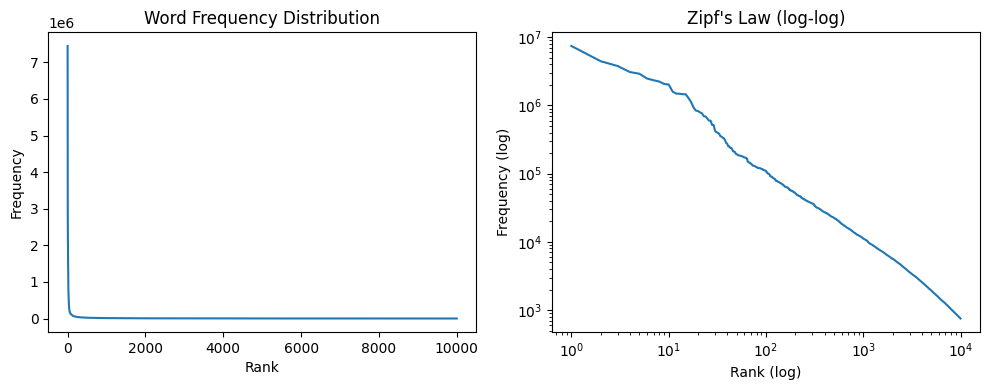

In [8]:
# Word frequency distribution (Zipf's law)
freqs = [counts[w] for w in idx2word]
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(freqs)
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Word Frequency Distribution")

plt.subplot(1, 2, 2)
plt.loglog(range(1, len(freqs) + 1), freqs)
plt.xlabel("Rank (log)")
plt.ylabel("Frequency (log)")
plt.title("Zipf's Law (log-log)")
plt.tight_layout()
plt.show()

## 2. Co-occurrence Matrix

We build a sparse symmetric co-occurrence matrix $M \in \mathbb{R}^{V \times V}$ where $M_{ij}$ counts how often words $i$ and $j$ appear within a window of 5 tokens of each other.

> **Note:** This step takes a few minutes on 17M tokens.

In [9]:
cooc = build_cooccurrence(tokens, word2idx, window=5)

print(f"Shape: {cooc.shape}")
print(f"Non-zero entries: {cooc.nnz:,}")
print(f"Density: {cooc.nnz / (V * V) * 100:.2f}%")
print(f"Is symmetric: {(cooc - cooc.T).nnz == 0}")

Mapping tokens to indices...
Building sparse matrix...
Shape: (10000, 10000)
Non-zero entries: 34,015,056
Density: 34.02%
Is symmetric: True


In [10]:
# Sanity check: co-occurrence counts for some word pairs
check_pairs = [("king", "queen"), ("the", "of"), ("dog", "cat"), ("man", "woman")]
print("Co-occurrence counts:")
for w1, w2 in check_pairs:
    if w1 in word2idx and w2 in word2idx:
        count = cooc[word2idx[w1], word2idx[w2]]
        print(f"  ({w1}, {w2}): {count:.0f}")

Co-occurrence counts:
  (king, queen): 1022
  (the, of): 4227853
  (dog, cat): 106
  (man, woman): 867


## 3. PPMI Weighting

Raw co-occurrence counts are dominated by frequent words ("the", "of", etc.). **PPMI** (Positive Pointwise Mutual Information) corrects for this:

$$\text{PPMI}(i,j) = \max\left(\log_2 \frac{P(i,j)}{P(i)\,P(j)},\ 0\right)$$

This highlights genuinely associated word pairs while suppressing spurious high-frequency co-occurrences.

In [11]:
from src.ppmi import compute_ppmi

ppmi_matrix = compute_ppmi(cooc)

print(f"PPMI non-zero entries: {ppmi_matrix.nnz:,}")
print(f"Min value: {ppmi_matrix.data.min():.4f} (should be > 0)")
print(f"Max value: {ppmi_matrix.data.max():.4f}")
print(f"Mean (non-zero): {ppmi_matrix.data.mean():.4f}")

PPMI non-zero entries: 22,679,967
Min value: 0.0000 (should be > 0)
Max value: 14.1393
Mean (non-zero): 1.6456


In [13]:
# Before/after PPMI comparison
print("Raw count vs PPMI for selected word pairs:")
print(f"{'Pair':<25s} {'Raw Count':>10s} {'PPMI':>10s}")
print("-" * 47)
for w1, w2 in check_pairs:
    if w1 in word2idx and w2 in word2idx:
        i, j = word2idx[w1], word2idx[w2]
        raw = cooc[i, j]
        ppmi_val = ppmi_matrix[i, j]
        print(f"({w1}, {w2}){'':<{20-len(w1)-len(w2)}} {raw:>10.0f} {ppmi_val:>10.4f}")

Raw count vs PPMI for selected word pairs:
Pair                       Raw Count       PPMI
-----------------------------------------------
(king, queen)                  1022     3.9496
(the, of)                   4227853     0.6568
(dog, cat)                      106     5.6185
(man, woman)                    867     4.6324


## 4. Truncated SVD & Word Vectors

We decompose the PPMI matrix using truncated SVD:

$$M_{\text{PPMI}} \approx U_k \Sigma_k V_k^T$$

The word vectors are computed as $E = U_k \sqrt{\Sigma_k}$ (symmetric weighting), which balances the contribution of singular values between left and right singular vectors.

In [24]:
from src.svd import compute_embeddings, get_word_vectors

k = 500
svd_result = compute_embeddings(ppmi_matrix, k=k)
U, S, Vt = svd_result["U"], svd_result["S"], svd_result["Vt"]

print(f"U shape: {U.shape}")
print(f"Singular values (top 10): {S[:10].round(2)}")
print(f"Singular values (bottom 5): {S[-5:].round(2)}")

U shape: (10000, 500)
Singular values (top 10): [3899.64 1759.65 1261.21 1176.99 1025.31  951.2   865.96  837.29  751.27
  696.25]
Singular values (bottom 5): [148.5  148.46 148.42 148.41 148.2 ]


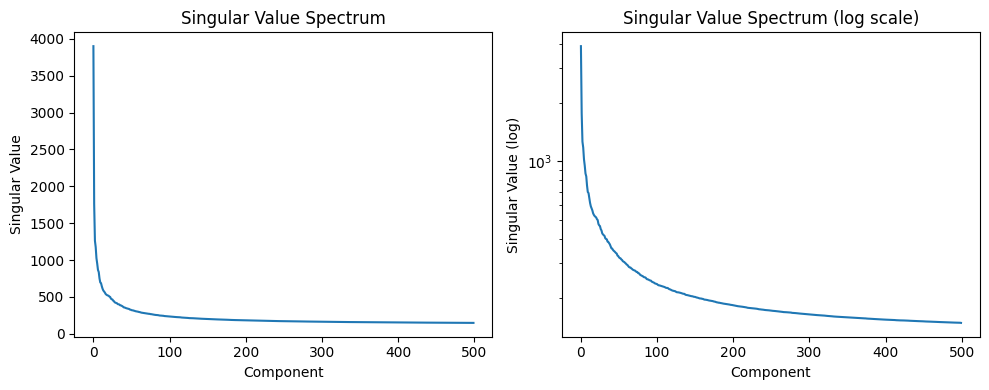

In [25]:
# Singular value spectrum
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(S)
plt.xlabel("Component")
plt.ylabel("Singular Value")
plt.title("Singular Value Spectrum")

plt.subplot(1, 2, 2)
plt.semilogy(S)
plt.xlabel("Component")
plt.ylabel("Singular Value (log)")
plt.title("Singular Value Spectrum (log scale)")
plt.tight_layout()
plt.show()

In [26]:
from src.evaluation import normalize, nearest_neighbours, analogy

E = get_word_vectors(U, S, variant="sqrt")
E_norm = normalize(E)

print("Quick sanity check — nearest neighbours for 'king':")
for word, score in nearest_neighbours("king", E_norm, idx2word, word2idx, n=10):
    print(f"  {word:15s} {score:.4f}")

Quick sanity check — nearest neighbours for 'king':
  throne          0.6779
  iii             0.6662
  iv              0.6328
  regent          0.6268
  queen           0.6233
  reigned         0.6051
  ii              0.5953
  prince          0.5940
  reign           0.5846
  vi              0.5828


## 5. Evaluation — Nearest Neighbours

Testing whether the learned vectors capture semantic similarity.

In [27]:
query_words = ["king", "dog", "computer", "france", "good"]

for qword in query_words:
    neighbours = nearest_neighbours(qword, E_norm, idx2word, word2idx, n=5)
    neighbour_str = ", ".join(f"{w} ({s:.3f})" for w, s in neighbours)
    print(f"{qword:12s} → {neighbour_str}")


king         → throne (0.678), iii (0.666), iv (0.633), regent (0.627), queen (0.623)
dog          → dogs (0.635), cat (0.595), breeds (0.547), breed (0.526), pet (0.482)
computer     → computers (0.751), computing (0.659), hardware (0.631), software (0.618), graphics (0.545)
france       → italy (0.609), spain (0.586), paris (0.575), belgium (0.565), french (0.551)
good         → bad (0.528), excellent (0.493), better (0.464), thing (0.435), things (0.434)


## 6. Evaluation — Word Analogies

Testing the classic analogy task: **a is to b as c is to ?**

The answer is computed as $\vec{b} - \vec{a} + \vec{c}$, then finding the nearest neighbour.

In [28]:
# Demo analogies
analogy_tests = [
    ("man", "king", "woman"),       # gender: king - man + woman ≈ queen
    ("france", "paris", "germany"), # capital: paris - france + germany ≈ berlin
    ("good", "better", "bad"),      # comparative: better - good + bad ≈ worse
    ("man", "men", "woman"),        # plural: men - man + woman ≈ women
]

print(f"{'a':>10s}  {'b':>10s}  {'c':>10s}  →  top predictions")
print("-" * 65)
for a, b, c in analogy_tests:
    results = analogy(a, b, c, E_norm, idx2word, word2idx, n=3)
    preds = ", ".join(f"{w} ({s:.3f})" for w, s in results)
    print(f"{a:>10s}  {b:>10s}  {c:>10s}  →  {preds}")

         a           b           c  →  top predictions
-----------------------------------------------------------------
       man        king       woman  →  queen (0.578), throne (0.553), regent (0.503)
    france       paris     germany  →  berlin (0.727), munich (0.669), vienna (0.636)
      good      better         bad  →  worse (0.454), harder (0.331), faster (0.321)
       man         men       woman  →  women (0.718), girls (0.416), male (0.388)


### Google Analogy Benchmark

The standard benchmark with 19,544 analogy questions across 14 categories (semantic + syntactic).

In [29]:
import os
import urllib.request

# Download Google Analogy Benchmark if not present
benchmark_path = "../data/questions-words.txt"
if not os.path.exists(benchmark_path):
    url = "https://raw.githubusercontent.com/nicholas-leonard/word2vec/master/questions-words.txt"
    print("Downloading Google Analogy Benchmark...")
    urllib.request.urlretrieve(url, benchmark_path)
    print("Done.")
else:
    print(f"Benchmark already exists at {benchmark_path}")

Benchmark already exists at ../data/questions-words.txt


In [30]:
from src.evaluation import load_google_analogy, evaluate_analogy_benchmark

categories = load_google_analogy(benchmark_path)
print(f"Loaded {sum(len(v) for v in categories.values()):,} questions in {len(categories)} categories")
for cat, qs in categories.items():
    print(f"  {cat}: {len(qs)} questions")

Loaded 19,544 questions in 14 categories
  capital-common-countries: 506 questions
  capital-world: 4524 questions
  currency: 866 questions
  city-in-state: 2467 questions
  family: 506 questions
  gram1-adjective-to-adverb: 992 questions
  gram2-opposite: 812 questions
  gram3-comparative: 1332 questions
  gram4-superlative: 1122 questions
  gram5-present-participle: 1056 questions
  gram6-nationality-adjective: 1599 questions
  gram7-past-tense: 1560 questions
  gram8-plural: 1332 questions
  gram9-plural-verbs: 870 questions


In [31]:
results = evaluate_analogy_benchmark(E_norm, idx2word, word2idx, categories)

# Display per-category results
rows = []
for cat, r in results["per_category"].items():
    rows.append({
        "Category": cat,
        "Correct": r["correct"],
        "Evaluated": r["total"],
        "OOV Skipped": r["oov_skipped"],
        "Accuracy": f"{r['accuracy']:.1%}",
    })

df = pd.DataFrame(rows)
display(df)

print(f"\nOverall accuracy: {results['overall_accuracy']:.1%}")
print(f"Total: {results['total_correct']}/{results['total_evaluated']} correct, {results['total_oov_skipped']} OOV skipped")

,Category,Correct,Evaluated,OOV Skipped,Accuracy
0,capital-common-countries,207,240,266,86.2%
1,capital-world,244,292,4232,83.6%
2,currency,1,18,848,5.6%
3,city-in-state,210,662,1805,31.7%
4,family,132,182,324,72.5%
5,gram1-adjective-to-adverb,50,306,686,16.3%
6,gram2-opposite,9,30,782,30.0%
7,gram3-comparative,373,552,780,67.6%
8,gram4-superlative,101,210,912,48.1%
9,gram5-present-participle,285,506,550,56.3%



Overall accuracy: 59.6%
Total: 3400/5701 correct, 13843 OOV skipped


## 7. Comparison — Effect of k

We run the full benchmark for $k \in \{50, 100, 200, 300, 500\}$ to find the optimal dimensionality.

In [22]:
k_values = [50, 100, 200, 300, 500]
k_results = {}

for k_val in k_values:
    print(f"Running SVD with k={k_val}...")
    svd_k = compute_embeddings(ppmi_matrix, k=k_val)
    E_k = get_word_vectors(svd_k["U"], svd_k["S"], variant="sqrt")
    E_k_norm = normalize(E_k)
    res = evaluate_analogy_benchmark(E_k_norm, idx2word, word2idx, categories)
    k_results[k_val] = res["overall_accuracy"]
    print(f"  k={k_val}: accuracy = {res['overall_accuracy']:.1%}")

print("\nDone.")

Running SVD with k=50...
  k=50: accuracy = 35.4%
Running SVD with k=100...
  k=100: accuracy = 47.1%
Running SVD with k=200...
  k=200: accuracy = 56.3%
Running SVD with k=300...
  k=300: accuracy = 58.1%
Running SVD with k=500...
  k=500: accuracy = 59.6%

Done.


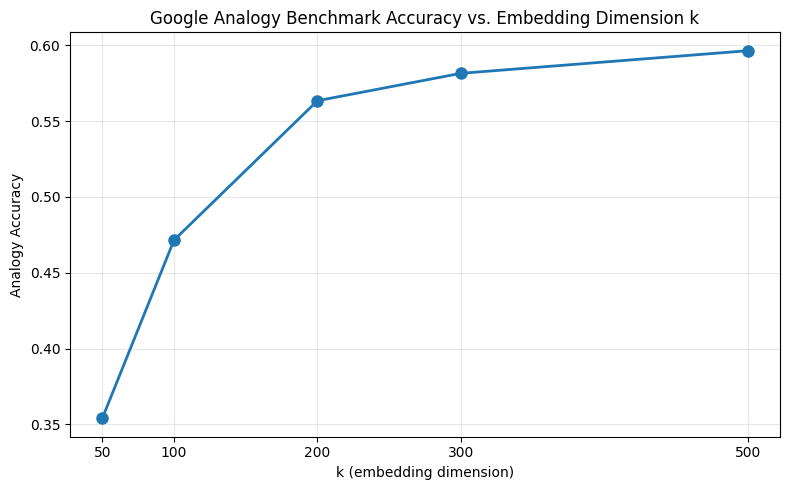

,k,Accuracy
0,50,35.4%
1,100,47.1%
2,200,56.3%
3,300,58.1%
4,500,59.6%


In [23]:
plt.figure(figsize=(8, 5))
plt.plot(list(k_results.keys()), list(k_results.values()), "o-", linewidth=2, markersize=8)
plt.xlabel("k (embedding dimension)")
plt.ylabel("Analogy Accuracy")
plt.title("Google Analogy Benchmark Accuracy vs. Embedding Dimension k")
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

df_k = pd.DataFrame([
    {"k": k, "Accuracy": f"{acc:.1%}"}
    for k, acc in k_results.items()
])
display(df_k)

## 8. Comparison — Embedding Variants

The report specifies three embedding variants derived from the SVD decomposition:
- **Plain:** $U_k$ — raw left singular vectors
- **Weighted:** $U_k \Sigma_k$ — fully weighted by singular values
- **Sqrt:** $U_k \sqrt{\Sigma_k}$ — symmetric weighting (our default)

In [32]:
variants = ["plain", "weighted", "sqrt"]
variant_results = {}

for var in variants:
    E_var = get_word_vectors(U, S, variant=var)
    E_var_norm = normalize(E_var)
    res = evaluate_analogy_benchmark(E_var_norm, idx2word, word2idx, categories)
    variant_results[var] = res["overall_accuracy"]
    print(f"Variant '{var}': accuracy = {res['overall_accuracy']:.1%}")

df_var = pd.DataFrame([
    {"Variant": v, "Formula": f, "Accuracy": f"{variant_results[v]:.1%}"}
    for v, f in zip(variants, ["U_k", "U_k · Σ_k", "U_k · √Σ_k"])
])
display(df_var)

Variant 'plain': accuracy = 58.3%
Variant 'weighted': accuracy = 54.9%
Variant 'sqrt': accuracy = 59.6%


,Variant,Formula,Accuracy
0,plain,U_k,58.3%
1,weighted,U_k · Σ_k,54.9%
2,sqrt,U_k · √Σ_k,59.6%


## 9. Comparison — Baselines

We compare our PPMI+SVD embeddings against:
1. **Raw co-occurrence cosine similarity** — no dimensionality reduction (naive baseline)
2. **GloVe** (300d, pre-trained on Wikipedia) — count-based neural alternative
3. **Word2Vec Skip-Gram** (300d, pre-trained on Google News) — neural SoTA reference

Raw co-occurrence cosine: 21.8%
GloVe: loaded 9982/10000 words
GloVe 300d: 79.4%
Word2Vec: loaded 9684/10000 words
Word2Vec 300d: 53.8%


,Method,Accuracy
0,Raw Co-occurrence,21.8%
1,PPMI + SVD (k=300),59.6%
2,GloVe 300d,79.4%
3,Word2Vec 300d,53.8%


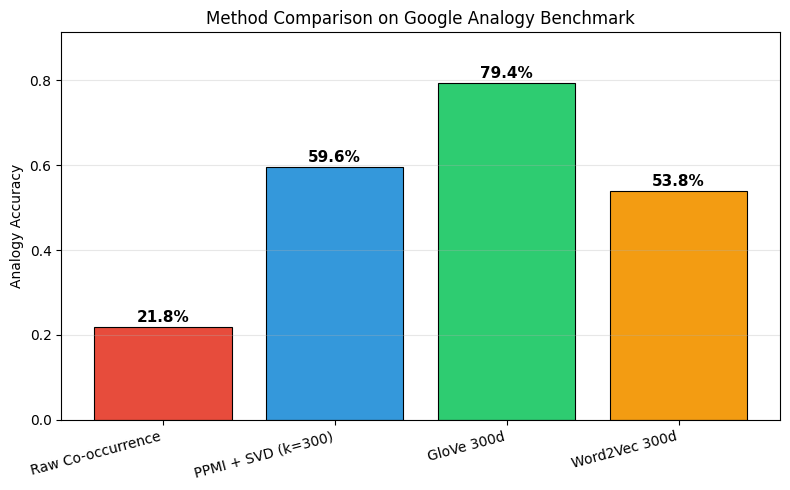

In [33]:
# Raw co-occurrence cosine similarity
from src.baselines import cosine_baseline_vectors

E_raw = cosine_baseline_vectors(cooc)  # already normalized
res_raw = evaluate_analogy_benchmark(E_raw, idx2word, word2idx, categories)
print(f"Raw co-occurrence cosine: {res_raw['overall_accuracy']:.1%}")

# GloVe 300d
# Download: https://nlp.stanford.edu/data/glove.6B.zip
from src.baselines import load_glove
import os

glove_path = "../data/glove.6B.300d.txt"
if os.path.exists(glove_path):
    E_glove = load_glove(glove_path, word2idx, dim=300)
    E_glove_norm = normalize(E_glove)
    res_glove = evaluate_analogy_benchmark(E_glove_norm, idx2word, word2idx, categories)
    glove_accuracy = res_glove["overall_accuracy"]
    print(f"GloVe 300d: {glove_accuracy:.1%}")
else:
    glove_accuracy = None
    print(f"GloVe file not found at {glove_path}")
    print("   Download from: https://nlp.stanford.edu/data/glove.6B.zip")

# Word2Vec Skip-Gram 300d
# Download: https://drive.google.com/file/d/0B7XkCwpI5KDYNlNUTTlSS21pQmM
w2v_path = "../data/GoogleNews-vectors-negative300.bin"
if os.path.exists(w2v_path):
    from src.baselines import load_word2vec
    E_w2v = load_word2vec(w2v_path, word2idx)
    E_w2v_norm = normalize(E_w2v)
    res_w2v = evaluate_analogy_benchmark(E_w2v_norm, idx2word, word2idx, categories)
    w2v_accuracy = res_w2v["overall_accuracy"]
    print(f"Word2Vec 300d: {w2v_accuracy:.1%}")
else:
    w2v_accuracy = None
    print(f"Word2Vec file not found at {w2v_path}")
    print("   Download from: https://drive.google.com/file/d/0B7XkCwpI5KDYNlNUTTlSS21pQmM")

comparison = {"Raw Co-occurrence": res_raw["overall_accuracy"], "PPMI + SVD (k=300)": results["overall_accuracy"]}
if glove_accuracy is not None:
    comparison["GloVe 300d"] = glove_accuracy
if w2v_accuracy is not None:
    comparison["Word2Vec 300d"] = w2v_accuracy

df_compare = pd.DataFrame([
    {"Method": m, "Accuracy": f"{a:.1%}"} for m, a in comparison.items()
])
display(df_compare)

plt.figure(figsize=(8, 5))
methods = list(comparison.keys())
accuracies = list(comparison.values())
colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"][:len(methods)]
bars = plt.bar(methods, accuracies, color=colors, edgecolor="black", linewidth=0.8)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f"{acc:.1%}", ha="center", va="bottom", fontweight="bold", fontsize=11)
plt.ylabel("Analogy Accuracy")
plt.title("Method Comparison on Google Analogy Benchmark")
plt.xticks(rotation=15, ha="right")
plt.ylim(0, max(accuracies) * 1.15)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 10. t-SNE Visualization
Project 500 selected words to 2D using t-SNE to verify semantic cluster formation.

Selected 450 words from 15 semantic groups
t-SNE completed. Output shape: (450, 2)


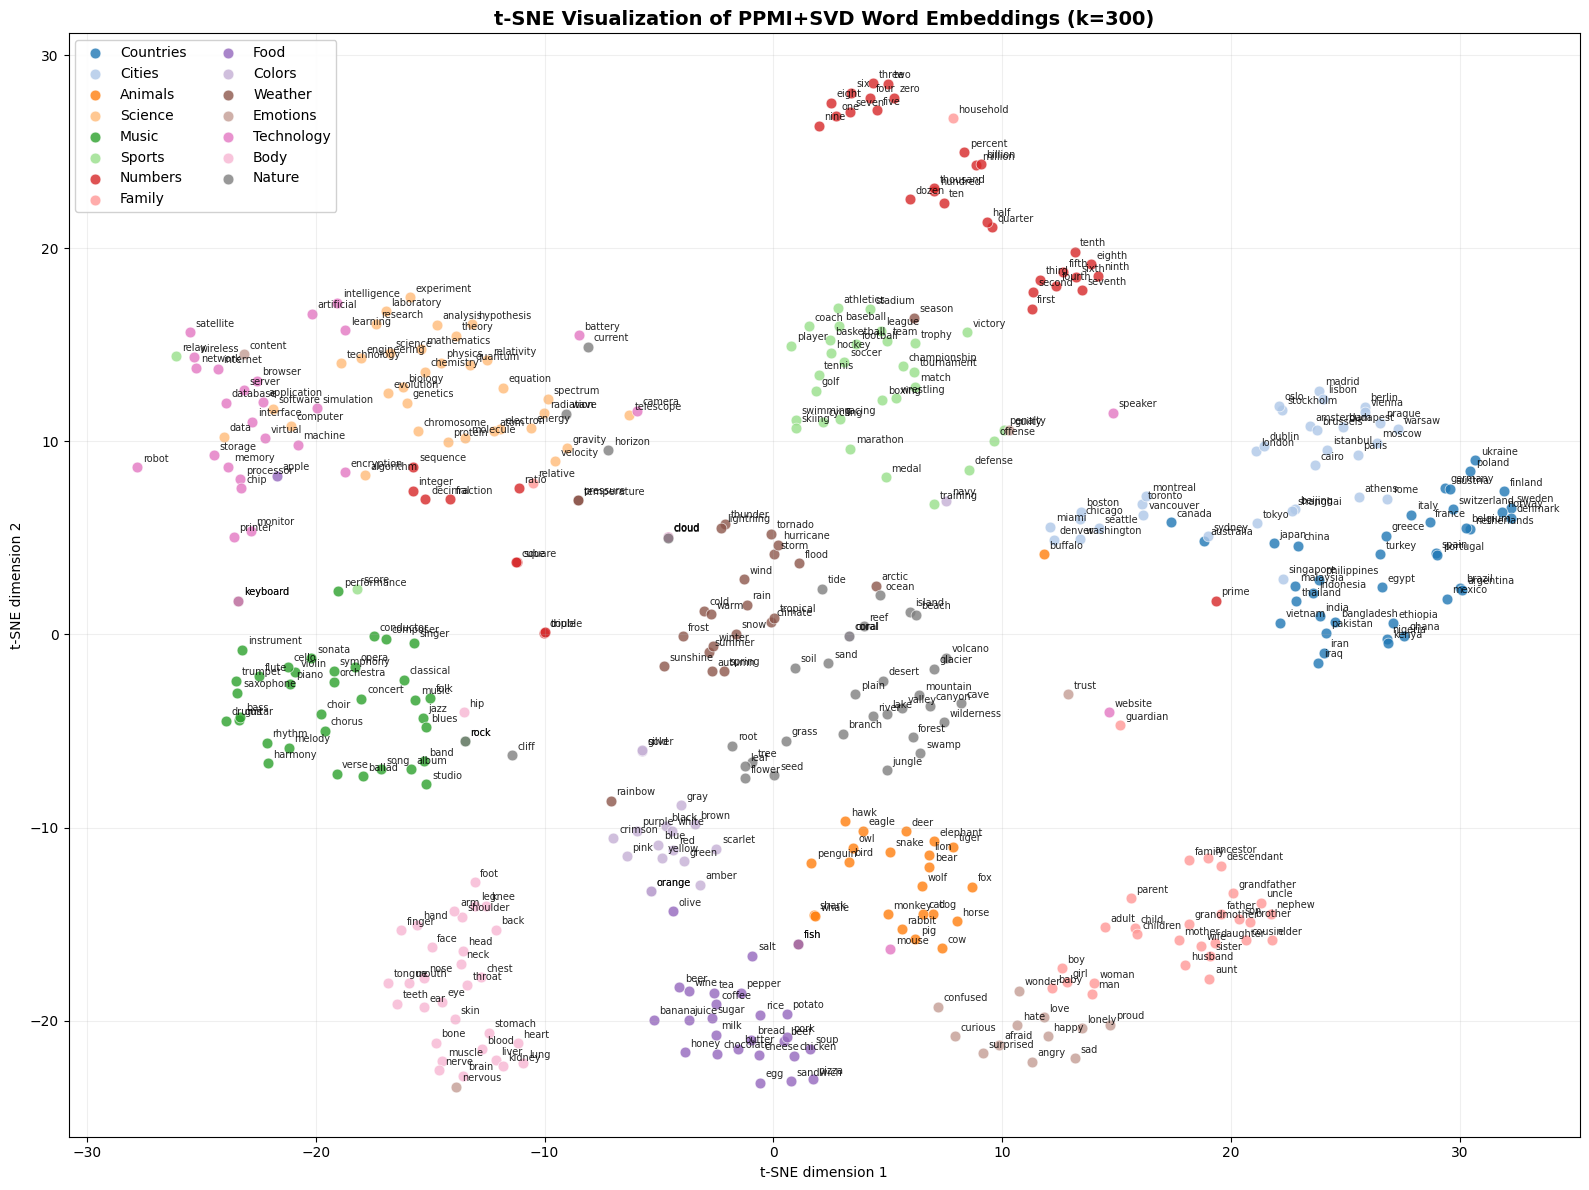

In [34]:
from sklearn.manifold import TSNE

semantic_groups = {
    "Countries": ["france", "germany", "italy", "spain", "china", "japan", "india", "brazil", "canada", "australia", "mexico", "egypt", "sweden", "norway", "poland", "greece", "turkey", "austria", "portugal", "argentina", "nigeria", "kenya", "ethiopia", "ghana", "iran", "iraq", "pakistan", "bangladesh", "vietnam", "thailand", "indonesia", "malaysia", "philippines", "ukraine", "netherlands", "belgium", "switzerland", "denmark", "finland"],
    "Cities": ["london", "paris", "berlin", "rome", "moscow", "tokyo", "beijing", "washington", "chicago", "boston", "sydney", "madrid", "dublin", "amsterdam", "vienna", "prague", "cairo", "stockholm", "oslo", "warsaw", "istanbul", "dubai", "singapore", "bangkok", "mumbai", "toronto", "montreal", "vancouver", "nairobi", "lagos", "seoul", "shanghai", "lisbon", "budapest", "athens", "brussels", "zurich", "denver", "miami", "seattle"],
    "Animals": ["dog", "cat", "horse", "bird", "fish", "bear", "lion", "tiger", "wolf", "deer", "eagle", "shark", "whale", "snake", "monkey", "rabbit", "elephant", "fox", "cow", "pig", "leopard", "cheetah", "giraffe", "zebra", "penguin", "dolphin", "crocodile", "gorilla", "chimpanzee", "parrot", "owl", "hawk", "flamingo", "buffalo", "rhinoceros", "hippopotamus", "camel", "kangaroo", "koala", "panda"],
    "Science": ["science", "physics", "chemistry", "biology", "mathematics", "computer", "engineering", "technology", "research", "theory", "experiment", "analysis", "data", "energy", "electron", "atom", "molecule", "equation", "algorithm", "software", "hypothesis", "laboratory", "microscope", "telescope", "quantum", "relativity", "evolution", "genetics", "ecosystem", "gravity", "radiation", "spectrum", "magnetism", "velocity", "photon", "neuron", "protein", "chromosome", "catalyst", "thermodynamics"],
    "Music": ["music", "song", "album", "band", "guitar", "piano", "jazz", "rock", "classical", "orchestra", "concert", "singer", "composer", "symphony", "melody", "rhythm", "opera", "choir", "folk", "blues", "violin", "cello", "trumpet", "saxophone", "drums", "bass", "keyboard", "conductor", "harmonica", "flute", "sonata", "ballad", "chorus", "verse", "tempo", "harmony", "instrument", "studio", "performance", "playlist"],
    "Sports": ["football", "basketball", "baseball", "soccer", "tennis", "golf", "hockey", "swimming", "boxing", "racing", "championship", "league", "coach", "player", "team", "score", "match", "victory", "stadium", "tournament", "volleyball", "cycling", "rowing", "skiing", "wrestling", "athletics", "marathon", "triathlon", "gymnastics", "archery", "referee", "penalty", "defense", "offense", "trophy", "medal", "training", "fitness", "sprint", "relay"],
    "Numbers": ["zero", "one", "two", "three", "four", "five", "six", "seven", "eight", "nine", "ten", "hundred", "thousand", "million", "billion", "first", "second", "third", "fourth", "fifth", "sixth", "seventh", "eighth", "ninth", "tenth", "dozen", "quarter", "half", "double", "triple", "quadruple", "percent", "fraction", "decimal", "integer", "prime", "square", "cube", "ratio", "sequence"],
    "Family": ["father", "mother", "son", "daughter", "brother", "sister", "husband", "wife", "uncle", "aunt", "grandfather", "grandmother", "boy", "girl", "man", "woman", "child", "children", "baby", "family", "cousin", "nephew", "niece", "stepfather", "stepmother", "godfather", "godmother", "sibling", "spouse", "parent", "grandchild", "toddler", "teenager", "adult", "elder", "guardian", "ancestor", "descendant", "relative", "household"],
    "Food": ["bread", "rice", "pasta", "soup", "salad", "pizza", "burger", "sandwich", "cheese", "butter", "milk", "egg", "sugar", "salt", "pepper", "chicken", "beef", "pork", "fish", "shrimp", "tomato", "potato", "onion", "garlic", "carrot", "apple", "banana", "orange", "strawberry", "chocolate", "coffee", "tea", "juice", "wine", "beer", "cake", "cookie", "ice cream", "honey", "olive"],
    "Colors": ["red", "blue", "green", "yellow", "orange", "purple", "pink", "brown", "black", "white", "gray", "silver", "gold", "turquoise", "indigo", "violet", "magenta", "cyan", "beige", "crimson", "scarlet", "emerald", "sapphire", "amber", "ivory", "maroon", "navy", "teal", "lavender", "coral"],
    "Weather": ["rain", "snow", "wind", "storm", "cloud", "sunshine", "thunder", "lightning", "fog", "hail", "rainbow", "hurricane", "tornado", "drought", "flood", "frost", "blizzard", "temperature", "humidity", "pressure", "forecast", "climate", "season", "spring", "summer", "autumn", "winter", "sunny", "cloudy", "overcast", "breeze", "gale", "heatwave", "cold", "warm", "tropical", "arctic", "monsoon", "typhoon", "sandstorm"],
    "Emotions": ["happy", "sad", "angry", "afraid", "surprised", "disgusted", "anxious", "excited", "bored", "lonely", "proud", "jealous", "grateful", "hopeful", "confused", "ashamed", "content", "curious", "frustrated", "nervous", "joyful", "melancholy", "nostalgic", "embarrassed", "confident", "guilty", "enthusiastic", "depressed", "calm", "irritated", "love", "hate", "grief", "wonder", "awe", "compassion", "envy", "trust", "disgust", "anticipation"],
    "Technology": ["internet", "website", "application", "database", "network", "server", "browser", "password", "encryption", "artificial", "intelligence", "machine", "learning", "blockchain", "cloud", "streaming", "processor", "memory", "storage", "interface", "keyboard", "monitor", "mouse", "printer", "camera", "microphone", "speaker", "battery", "wireless", "bluetooth", "satellite", "robot", "automation", "cybersecurity", "virtual", "augmented", "simulation", "sensor", "drone", "chip"],
    "Body": ["head", "face", "eye", "ear", "nose", "mouth", "teeth", "tongue", "neck", "shoulder", "arm", "elbow", "wrist", "hand", "finger", "chest", "heart", "lung", "stomach", "back", "hip", "leg", "knee", "ankle", "foot", "toe", "brain", "bone", "muscle", "skin", "blood", "nerve", "liver", "kidney", "spine", "throat", "jaw", "forehead", "cheek", "heel"],
    "Nature": ["mountain", "river", "ocean", "forest", "desert", "valley", "island", "volcano", "glacier", "waterfall", "canyon", "beach", "jungle", "meadow", "lake", "cave", "cliff", "reef", "swamp", "plain", "soil", "rock", "sand", "grass", "flower", "tree", "leaf", "seed", "root", "branch", "moss", "fern", "seaweed", "coral", "cloud", "wave", "tide", "current", "horizon", "wilderness"],
}

selected_words = []
word_categories = []
for category, words in semantic_groups.items():
    for w in words:
        if w in word2idx:
            selected_words.append(w)
            word_categories.append(category)

selected_indices = [word2idx[w] for w in selected_words]
print(f"Selected {len(selected_words)} words from {len(semantic_groups)} semantic groups")

E_selected = E_norm[selected_indices]
tsne = TSNE(n_components=2, perplexity=30, random_state=42, learning_rate="auto")
E_2d = tsne.fit_transform(E_selected)
print(f"t-SNE completed. Output shape: {E_2d.shape}")

fig, ax = plt.subplots(figsize=(16, 12))

category_names = list(semantic_groups.keys())
cmap = colormaps.get_cmap("tab20")
cat_to_color = {cat: cmap(i) for i, cat in enumerate(category_names)}

for cat in category_names:
    mask = [c == cat for c in word_categories]
    x = E_2d[mask, 0]
    y = E_2d[mask, 1]
    ax.scatter(x, y, c=[cat_to_color[cat]], label=cat, s=60, alpha=0.8, edgecolors="white", linewidths=0.5)

for i, word in enumerate(selected_words):
    ax.annotate(word, (E_2d[i, 0], E_2d[i, 1]),
                fontsize=7, alpha=0.85,
                xytext=(4, 4), textcoords="offset points")

ax.legend(fontsize=10, loc="upper left", framealpha=0.9, ncol=2)
ax.set_title("t-SNE Visualization of PPMI+SVD Word Embeddings (k=300)", fontsize=14, fontweight="bold")
ax.set_xlabel("t-SNE dimension 1")
ax.set_ylabel("t-SNE dimension 2")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()
